# Sharing and Importing Tools

In this notebook, I explore how tools can be shared and reused using the Hugging Face `smolagents` library.

I will learn how to:

- Share a custom tool on the Hugging Face Hub
- Import an existing tool from the Hugging Face Hub
- Use a Hugging Face Space as a tool
- Explore integration with LangChain tools
- Explore MCP tool collections

## 1. Preparing a Custom Tool

Before sharing a tool on the Hugging Face Hub, we first need to create or instantiate the custom tool that we want to share.

In this example, I will use a custom `SuperheroPartyThemeTool` that generates superhero-themed party ideas based on a given category.

In [1]:
from smolagents import Tool, CodeAgent, InferenceClientModel

class SuperheroPartyThemeTool(Tool):
    name = "superhero_party_theme_generator"

    description = """
    This tool suggests creative superhero-themed party ideas based on a category.
    """

    inputs = {
        "category": {
            "type": "string",
            "description": "The type of superhero party."
        }
    }

    output_type = "string"

    def forward(self, category: str):
        themes = {
            "classic heroes": "Justice League Gala with superhero costumes and themed drinks.",
            "villain masquerade": "Gotham Rogues' Ball where guests dress as famous villains.",
            "futuristic gotham": "Neo-Gotham Night with cyberpunk decorations and futuristic gadgets."
        }

        return themes.get(
            category.lower(),
            "Theme not found."
        )

## 2. Instantiating and Testing the Tool

After defining the custom tool, I create an instance of it.

Before sharing the tool on the Hugging Face Hub, I test it locally to make sure it works correctly.

In [4]:
party_theme_tool = SuperheroPartyThemeTool()

party_theme_tool.forward("villain masquerade")

"Gotham Rogues' Ball where guests dress as famous villains."

## 3. Sharing the Tool to the Hugging Face Hub

The `smolagents` library allows custom tools to be shared on the Hugging Face Hub.

Using the `push_to_hub()` method, the tool can be uploaded to a Hugging Face repository and reused later.

In [ ]:
party_theme_tool.push_to_hub(
    "rudraksht/party_theme_tool"
)

### Note

When attempting to share the tool using `push_to_hub()`, Hugging Face returned a `402 Payment Required` error because the current account does not have access to create the required Gradio Space on the available hardware tier.

The custom tool was successfully created and tested locally, but publishing it as a hosted Hugging Face Space was not available with the current account configuration.

## 3. Importing a Tool from the Hugging Face Hub

Instead of creating every tool from scratch, `smolagents` allows us to load tools that have already been shared on the Hugging Face Hub.

In this example, I load an existing text-to-image tool and provide it to a `CodeAgent`.

In [7]:
from smolagents import load_tool, CodeAgent, InferenceClientModel

image_generation_tool = load_tool(
    "m-ric/text-to-image",
    trust_remote_code=True
)

tool.py:   0%|          | 0.00/635 [00:00<?, ?B/s]

## 4. Creating an Agent with the Imported Tool

After loading the tool from the Hugging Face Hub, I can provide it to a `CodeAgent`.

The agent can then use the imported tool as one of its capabilities.

In [8]:
model = InferenceClientModel(
    model_id="Qwen/Qwen2.5-Coder-32B-Instruct"
)

agent = CodeAgent(
    tools=[image_generation_tool],
    model=model
)

## 5. Running the Agent with the Imported Tool

Now I give the agent a task that requires image generation.

The agent can decide to use the text-to-image tool that was loaded directly from the Hugging Face Hub.

In [12]:
result = agent.run(
    "Generate an image of a luxurious superhero-themed party at Wayne Manor with fictional superheroes."
)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate an image of a luxurious superhero-themed party at Wayne Manor with fictional superheroes.              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  prompt = "high-res, photorealistic scene of a luxurious superhero-themed party at Wayne Manor, featuring iconic  
  characters like Batman, Superman, Wonder Woman, and iconic villains such as Joker and Harley Quinn in glamorous  
  attire, with elegant decor, grand hall, chandeliers, and modern lighting"                                        
  image = image_generator(prompt)                                                                                  
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x1641D9E50>

[Step 1: Duration 8.34 seconds| Input tokens: 2,108 | Output tokens: 123]

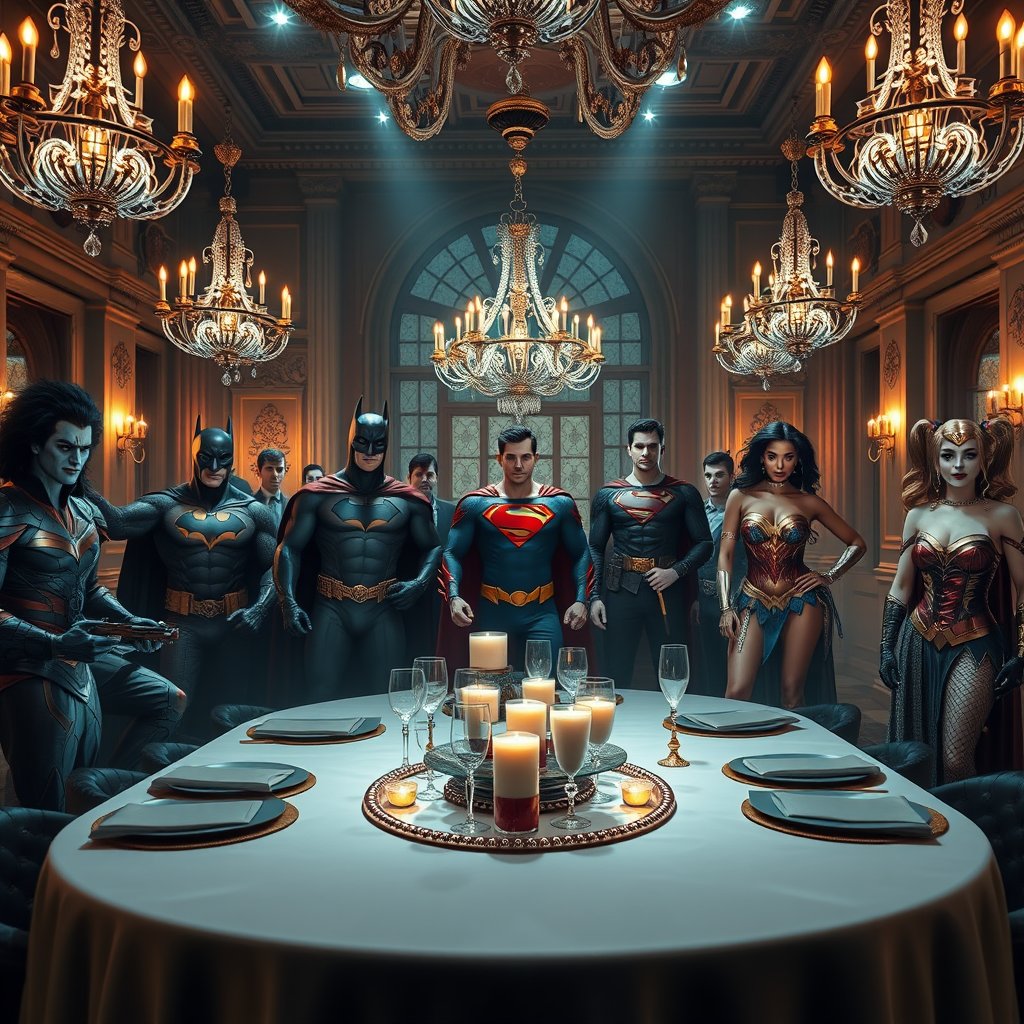

In [14]:
from IPython.display import display

display(result)

## 3. Importing a Hugging Face Space as a Tool

Hugging Face Spaces can also be integrated as tools using `Tool.from_space()`.

This allows an agent to use applications hosted on Hugging Face Spaces as part of its workflow.

In [ ]:
from smolagents import CodeAgent, InferenceClientModel, Tool

image_generation_tool = Tool.from_space(
    "black-forest-labs/FLUX.1-schnell",
    name="image_generator",
    description="Generate an image from a prompt"
)

### Note

When attempting to import the Hugging Face Space using `Tool.from_space()`, a compatibility error occurred between the installed versions of `smolagents` and `gradio_client`.

The error was:

`TypeError: Client.__init__() got an unexpected keyword argument 'hf_token'`

The concept and implementation of `Tool.from_space()` were explored, but the Space could not be connected in the current environment due to this dependency compatibility issue.